# Bayesian BLP: Structural Demand Estimation on Aggregate Market Shares


Discrete choice modelling is derived from the idea that choices are determined by subjective estimates of utility. That's a useful lens when we have information about the individual actors who are making choices in the market. It's a frustrating gap in the data when we only have aggregate sales statistics. How can we infer latent utility from market wide patterns? Is this not simply a case of the ecological fallacy?

Let's assume we have two markets only: 

- Market A: 40% share for sugary cereal, average income $30k
- Market B: 60% share for sugary cereal, average income $50k

If we try and naively disaggregate we might conclude that: "Higher income causes people to buy more sugary cereal." In reality, it's perfectly possible that within each market lower-income households tend to buy more sugary cereal, but that market B happens to have a younger population that drives higher incomes and sugary cereal consumption. There are at least two dimensions to this problem worth calling out: (1) this is a kind of selection effect problem where Markets is a confounder, and the aggregation over heterogenous markets biases our conclusions and (2) the extremity of the difference between the global view and the within market view is unobserved. We could have an extreme Simpson's paradox style reversal, or just a muted effect. This mistaken generalisation - moving from aggregate metrics to unit-level claims - is called the ecological fallacy.

### BLP's Big Idea

How then we can we move from aggregate data to sensible utility based implications? In particular, how can we think about the effect of price movements on demand? We must assume that there are different degrees of price sensitivity latent in each market. If we can make this assumption, the next natural question is what is the shape and contours of the preference distribution implied by the observed data. BLP models don't try to reconstruct individual attributes from aggregate data. Instead, they integrate over the possible distribution of preferences and ask: "What distribution of individual preferences would generate these aggregate shares? This is a canonical Bayesian question. 

#### Halton Draws and Taste Profiles

Practically, we need to think about how to encode the preference distribution, so which unit-level taste profiles best predict market level shares. 


## When to use this model

PyMC-Marketing ships three discrete-choice model families. Choosing the right one
avoids both under-fitting and unnecessary complexity:

| Model | Data shape | What it answers |
|---|---|---|
| **MNL / MixedLogit** | Individual choice occasions | Who chose what, and why? |
| **MVITS** | Aggregate share time series | What happened when brand X launched? |
| **BayesianBLP** *(this notebook)* | Aggregate share panels | What would happen if I changed price? |

**BayesianBLP** is a *structural* random-coefficients logit on aggregate shares — the
Bayesian reformulation of Berry, Levinsohn & Pakes (1995) following Jiang, Manchanda
& Rossi (2009). It is the right tool when:

- You only have **aggregate market shares** (not individual transactions).
- You need structurally grounded **cross-price substitution patterns**.
- Prices may be **endogenous** (set by firms who observe unobserved demand shocks)
  and you have **cost or rival-characteristic instruments** to correct for the bias.
- You want **full posterior uncertainty** on elasticities and counterfactual shares,
  with correct propagation through the structural demand model.

The Bayesian formulation replaces the classical BLP contraction mapping + GMM with a
joint posterior over preference parameters and the latent demand shocks ξ_jt. This
makes hierarchical pooling across regions cheap and returns honest credible intervals
even under weak instruments.


In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np

from pymc_marketing.customer_choice import BayesianBLP, generate_blp_panel

warnings.filterwarnings("ignore")
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 5]
plt.rcParams["figure.dpi"] = 100
%config InlineBackend.figure_format = 'retina'

/Users/nathaniel.forde/.local/share/mamba/envs/pymc-marketing-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Synthetic data: a BLP-style aggregate share panel

We use `generate_blp_panel` to create a synthetic panel with known true parameters.
The data-generating process produces a joint `(η_jt, ξ̃_jt)` shock so that prices
are **endogenous** — naive estimation without instruments will bias the price
coefficient toward zero.

The returned DataFrame is in long format: one row per (market, product), with the
outside good as a special row labelled `'outside'`. The `truth` dictionary records
the DGP parameters we will try to recover.

**Market semantics.** A BLP "market" is a `(region, period)` cell — the unit at
which shares and prices are observed. The model treats markets as exchangeable
unless you tell it otherwise: pass `time_col="period"` to `BayesianBLP` to
expose `period` as a first-class coordinate. Then `counterfactual_shares` and
`elasticities` accept `periods=` / `regions=` coord-label arguments so you can
phrase questions like "raise prod_0 price by 10% in periods 10–20" directly,
rather than reverse-engineering a flat market index. This notebook turns that
on at construction so the time-targeted counterfactual section near the end
just works.


In [2]:
df, truth = generate_blp_panel(
    T=40,  # markets (think: 40 weeks)
    J=3,  # inside products
    K=2,  # product characteristics
    L=2,  # instruments per product
    true_alpha=-2.0,
    true_beta=np.array([0.8, 1.2]),
    sigma_alpha=0.5,  # std of consumer price heterogeneity
    instrument_strength=0.7,  # first-stage R² ≈ 0.49
    price_xi_corr=0.6,  # endogeneity severity
    market_size=4_000,
    n_dgp_draws=3_000,
    random_seed=42,
    return_truth=True,
)

print(
    f"Panel: {df['market'].nunique()} markets × {len(truth['characteristic_cols'])} "
    f"characteristics + {len(truth['instrument_cols'])} instruments"
)
print(f"True alpha (price):  {truth['alpha']:.3f}")
print(f"True beta:           {truth['beta']}")
print(f"True sigma_alpha:    {truth['sigma_alpha']:.3f}")
print(f"Outside share mean:  {df[df['product'] == 'outside']['share'].mean():.3f}")

Panel: 40 markets × 2 characteristics + 2 instruments
True alpha (price):  -2.000
True beta:           [0.8 1.2]
True sigma_alpha:    0.500
Outside share mean:  0.667


In [3]:
df.head(8)

,region,market,period,product,share,n,price,x_0,x_1,z_0,z_1
0,r0,0,0,outside,0.9315,4000,0.000000,0.0,0.000000,0.000000,0.000000
1,r0,0,0,prod_0,0.0005,4000,4.124200,0.0,-0.863345,0.006339,2.597674
2,r0,0,0,prod_1,0.0380,4000,1.210960,0.0,-0.147529,0.223080,1.433215
3,r0,0,0,prod_2,0.0300,4000,1.987674,0.0,-0.152523,0.091520,0.580777
4,r0,1,1,outside,0.5560,4000,0.000000,0.0,0.000000,0.000000,0.000000
5,r0,1,1,prod_0,0.3985,4000,0.929217,1.0,0.383394,-0.056783,-0.170408
6,r0,1,1,prod_1,0.0445,4000,2.298272,1.0,0.999824,-0.779482,0.430301
7,r0,1,1,prod_2,0.0010,4000,3.006346,0.0,-1.058536,-0.851537,0.665585


## 2. Model specification and prior predictive check

We instantiate `BayesianBLP` with:
- `random_coef_on=['price']` — consumer-level price heterogeneity `α_i = α_r + σ_α · ν_i`
- `instruments=truth['instrument_cols']` — enables the price-endogeneity correction
- `n_mc_draws=100` — Owen-scrambled Halton draws for the share integral (use ≥ 200 in practice)

A prior predictive check confirms that the priors put mass on shares that are
plausible for scanner data (no pathological predictions).


In [4]:
model = BayesianBLP(
    market_data=df,
    characteristics=truth["characteristic_cols"],
    instruments=truth["instrument_cols"],
    random_coef_on=["price"],
    time_col="period",
    n_mc_draws=100,
    random_seed=0,
)
model

Sampling: [alpha, beta, log_share_ratio, pi_0, pi_z, price_obs, rho_price_xi, sigma_eta, sigma_random, sigma_xi, sigma_xi_j, xi_j_raw, xi_tilde_raw]


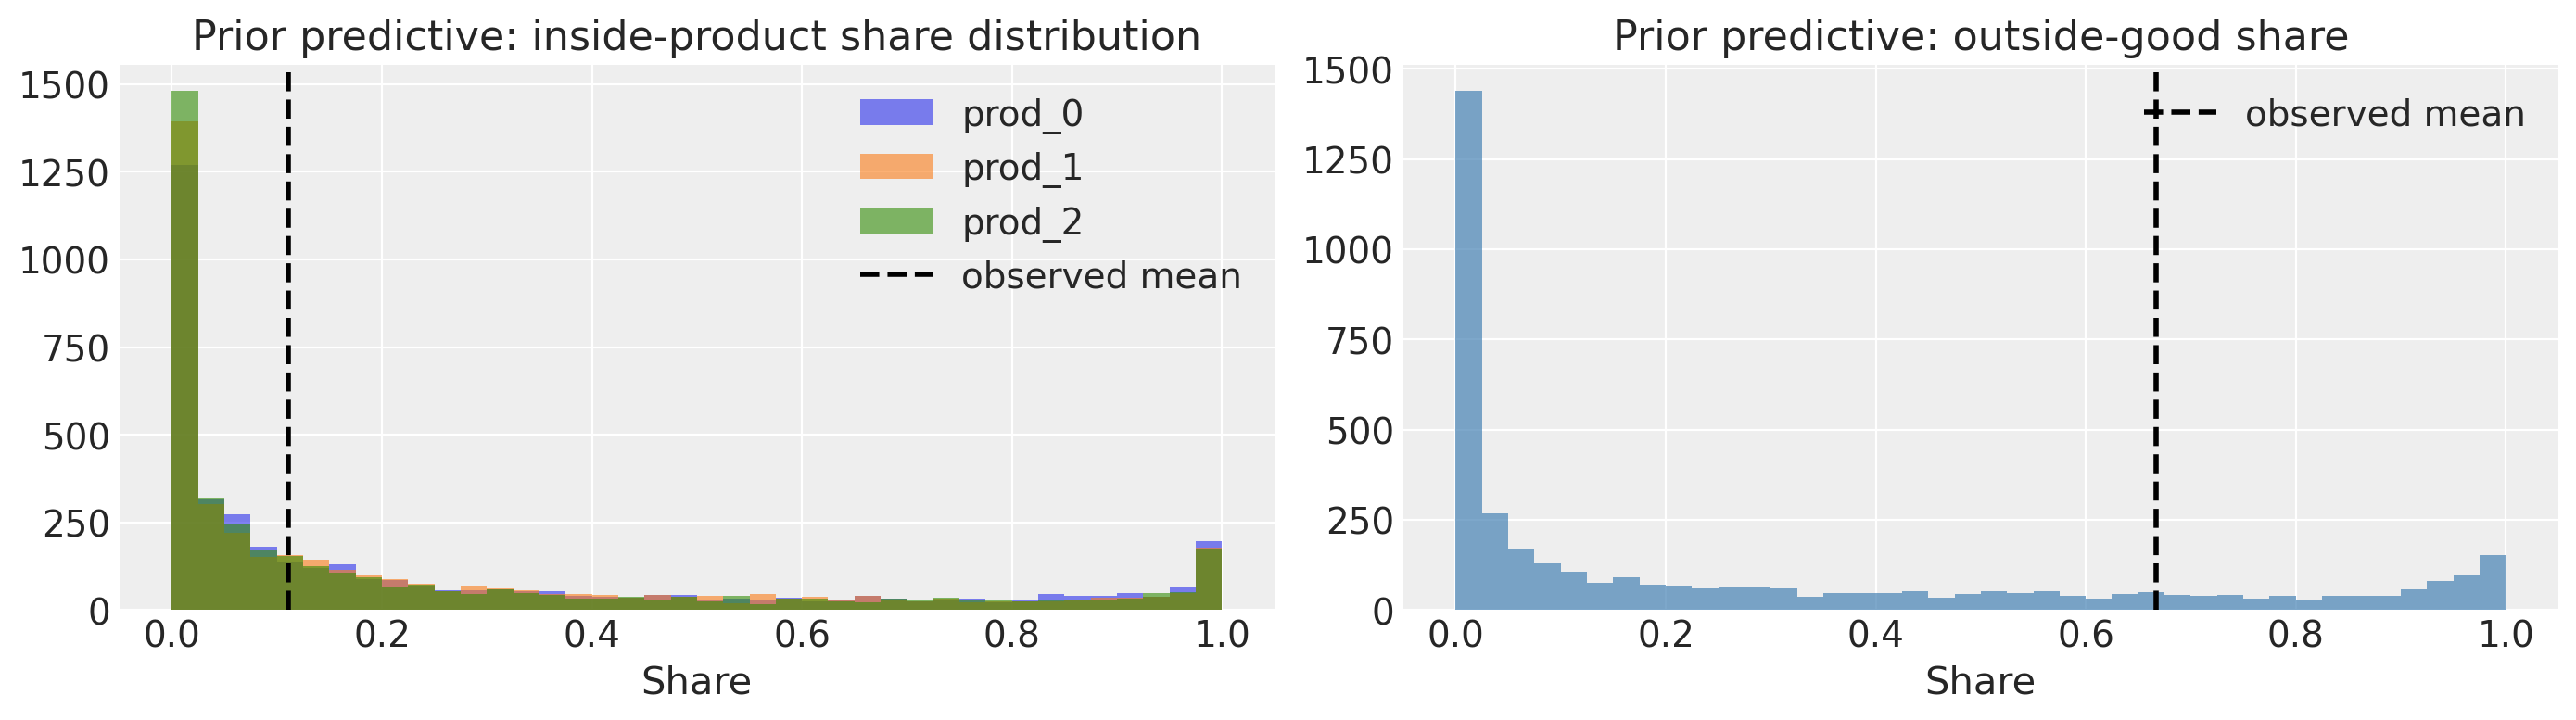

Shares sum to 1: True


In [5]:
prior = model.sample_prior_predictive(samples=100)

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# Inside shares
s_in_prior = prior.prior["s_inside"].values.reshape(-1, model._M, model._J)
for j, pname in enumerate(model._inside_products):
    axs[0].hist(s_in_prior[:, :, j].ravel(), bins=40, alpha=0.6, label=pname)
axs[0].axvline(
    df[df["product"] != "outside"].groupby("product")["share"].mean().mean(),
    color="k",
    lw=2,
    ls="--",
    label="observed mean",
)
axs[0].set_title("Prior predictive: inside-product share distribution")
axs[0].set_xlabel("Share")
axs[0].legend()

# Outside share
s_out_prior = prior.prior["s_outside"].values.ravel()
axs[1].hist(s_out_prior, bins=40, color="steelblue", alpha=0.7)
axs[1].axvline(
    df[df["product"] == "outside"]["share"].mean(),
    color="k",
    lw=2,
    ls="--",
    label="observed mean",
)
axs[1].set_title("Prior predictive: outside-good share")
axs[1].set_xlabel("Share")
axs[1].legend()

plt.tight_layout()
plt.show()
print(
    f"Shares sum to 1: "
    f"{np.allclose(s_in_prior.sum(axis=-1) + prior.prior['s_outside'].values[0], 1.0)}"
)

## 3. Fitting the model with instruments

The model is fit with the `numpyro` backend. We use deliberately small draw counts
here for speed — in practice use `draws=2000, tune=2000, chains=4`.

The key sampler settings:
- `nuts_sampler='numpyro'` — JAX-accelerated NUTS, essential for the ξ̃_jt block
- `target_accept=0.95` — the default; the funnel-prone ξ̃ block warrants a high
  acceptance target


In [6]:
_FIT_KWARGS = dict(
    nuts_sampler="nutpie",
    draws=1000,
    tune=1000,
    chains=4,
    progressbar=True,
    random_seed=0,
)

model.fit(**_FIT_KWARGS)
n_div = int(model.idata.sample_stats["diverging"].values.sum())
print(f"Divergences: {n_div}")  # should be 0

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.07,63
,2000,1,0.07,63
,2000,0,0.06,63
,2000,0,0.07,63


Divergences: 1


## 4. Posterior summary and parameter recovery

We check whether the fitted posterior recovers the known DGP parameters.
The key structural parameters are:

- `alpha_r` — the (mean-field) price coefficient; should be negative and close to
  the true value
- `beta_r` — characteristic utility weights; should recover `true_beta`
- `sigma_random` — standard deviation of consumer-level price heterogeneity
- `rho_price_xi` — the endogeneity correlation (how much ξ co-moves with price
  residuals); a positive value confirms that price is endogenous


In [7]:
key_vars = ["alpha_r", "beta_r", "sigma_random", "rho_price_xi"]
az.summary(model.idata, var_names=key_vars, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_r[all],-2.01,0.07,-2.14,-1.90,0.00,0.0,196.61,394.03,1.02
"beta_r[all, x_0]",0.79,0.05,0.70,0.88,0.00,0.0,413.20,865.10,1.01
"beta_r[all, x_1]",1.19,0.03,1.14,1.24,0.00,0.0,300.64,610.34,1.02
sigma_random[price],0.55,0.04,0.47,0.64,0.00,0.0,364.34,820.65,1.01
rho_price_xi,0.58,0.11,0.39,0.77,0.01,0.0,205.24,442.91,1.02


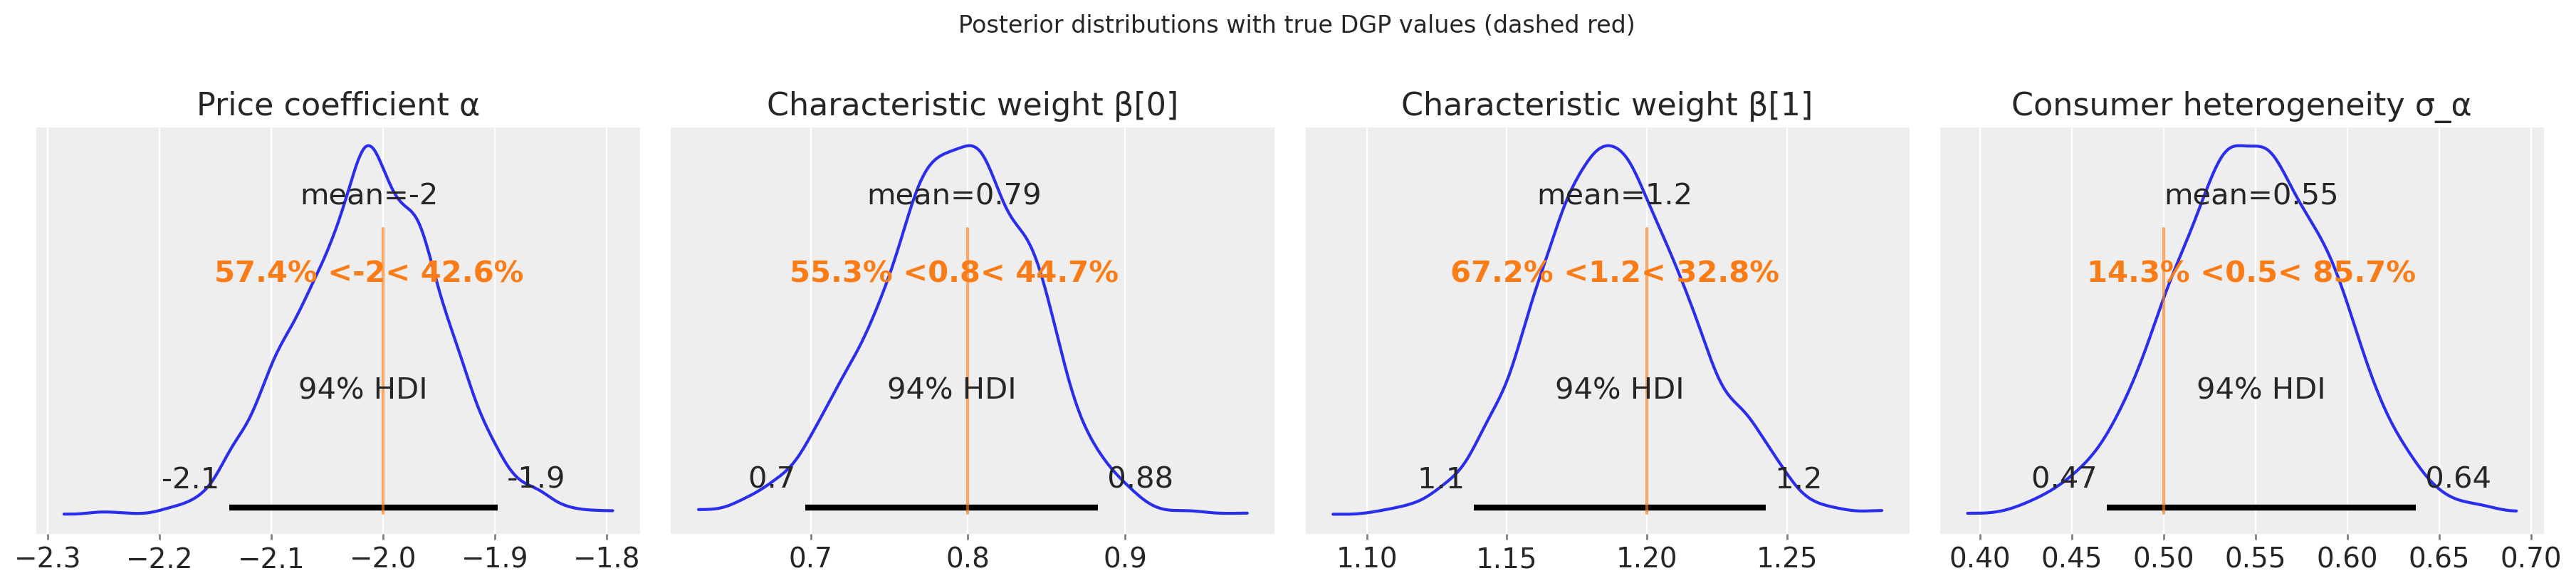

In [8]:
fig, axs = plt.subplots(1, 4, figsize=(18, 4))

truth_vals = {
    "alpha_r": truth["alpha"],
    "beta_r[0]": truth["beta"][0],
    "beta_r[1]": truth["beta"][1],
    "sigma_random[0]": truth["sigma_alpha"],
}

ax = axs[0]
az.plot_posterior(model.idata, var_names=["alpha_r"], ref_val=truth["alpha"], ax=ax)
ax.set_title("Price coefficient α")

beta_post = model.idata.posterior["beta_r"].values.reshape(
    -1, model._J if model.region_col else 1, 2
)
for k, ax in zip(range(2), axs[1:3], strict=True):
    az.plot_posterior(
        model.idata,
        var_names=["beta_r"],
        coords={"characteristic": truth["characteristic_cols"][k]},
        ref_val=float(truth["beta"][k]),
        ax=ax,
    )
    ax.set_title(f"Characteristic weight β[{k}]")

az.plot_posterior(
    model.idata,
    var_names=["sigma_random"],
    coords={"random_coef": "price"},
    ref_val=truth["sigma_alpha"],
    ax=axs[3],
)
axs[3].set_title("Consumer heterogeneity σ_α")

plt.suptitle("Posterior distributions with true DGP values (dashed red)", y=1.02)
plt.tight_layout()
plt.show()

## 5. Endogeneity correction: IV vs. no-IV

The headline feature of BLP is the endogeneity correction. When prices are
set by firms that observe unobserved demand shocks ξ_jt, naively regressing
shares on prices overstates willingness-to-pay (biases α toward zero).

We fit a second model *without* instruments to illustrate the bias. With
`price_xi_corr=0.6`, the no-IV estimator is expected to recover an alpha
substantially less negative than the truth.


In [9]:
# Fit without instruments (endogeneity bias expected)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_noiv = BayesianBLP(
        market_data=df,
        characteristics=truth["characteristic_cols"],
        instruments=None,  # no IV
        random_coef_on=["price"],
        n_mc_draws=100,
        random_seed=0,
    )
    model_noiv.fit(**_FIT_KWARGS)

iv_alpha = float(model.idata.posterior["alpha_r"].values.mean())
noiv_alpha = float(model_noiv.idata.posterior["alpha_r"].values.mean())

print(f"True alpha:            {truth['alpha']:+.3f}")
print(
    f"IV posterior mean:     {iv_alpha:+.3f}  "
    f"(bias {abs(truth['alpha'] - iv_alpha):.3f})"
)
print(
    f"no-IV posterior mean:  {noiv_alpha:+.3f}  "
    f"(bias {abs(truth['alpha'] - noiv_alpha):.3f})"
)
print()
if abs(truth["alpha"] - noiv_alpha) > abs(truth["alpha"] - iv_alpha):
    print("✓  IV fit is closer to truth, endogeneity correction is working.")
else:
    print("✗  Unexpected — check the seed / DGP.")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,14,0.08,63
,2000,0,0.07,63
,2000,0,0.08,127
,2000,0,0.08,31


True alpha:            -2.000
IV posterior mean:     -2.013  (bias 0.013)
no-IV posterior mean:  -1.910  (bias 0.090)

✓  IV fit is closer to truth, endogeneity correction is working.


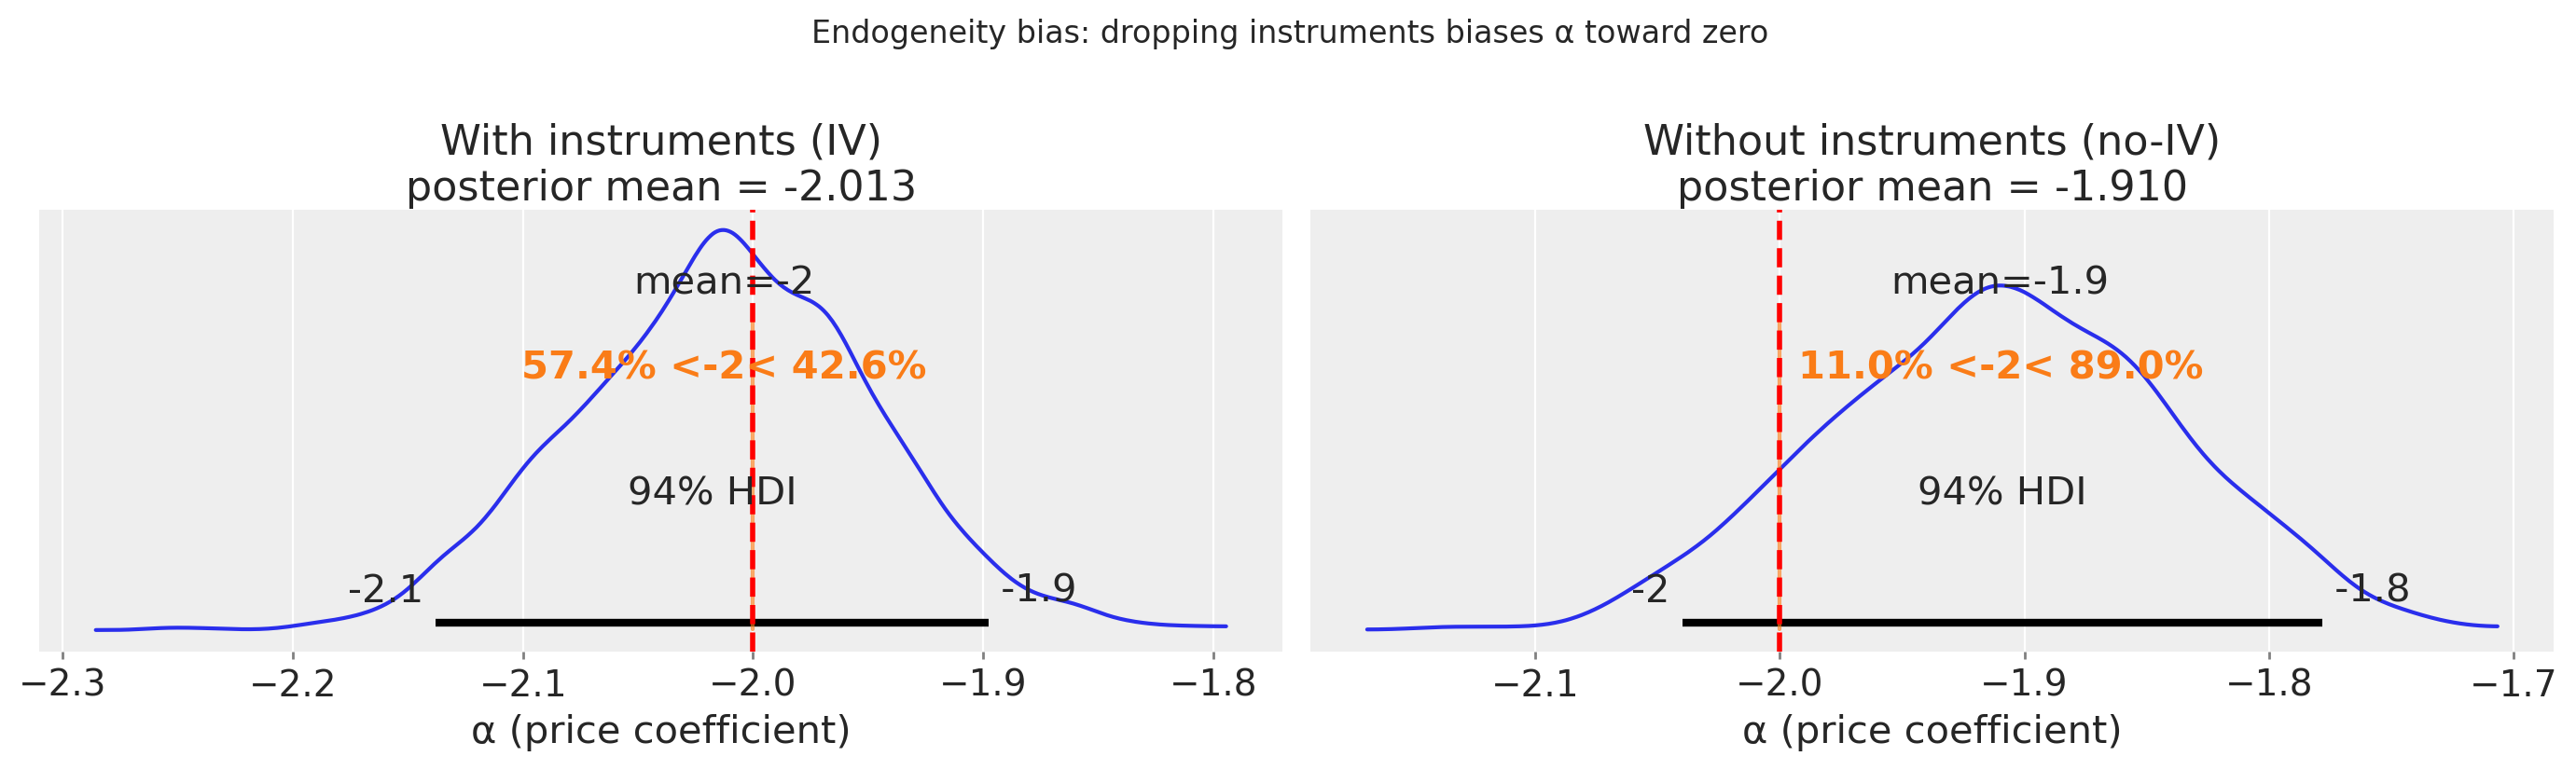

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

az.plot_posterior(
    model.idata,
    var_names=["alpha_r"],
    ref_val=truth["alpha"],
    ax=axs[0],
)
axs[0].set_title(f"With instruments (IV)\nposterior mean = {iv_alpha:.3f}")

az.plot_posterior(
    model_noiv.idata,
    var_names=["alpha_r"],
    ref_val=truth["alpha"],
    ax=axs[1],
)
axs[1].set_title(f"Without instruments (no-IV)\nposterior mean = {noiv_alpha:.3f}")

for ax in axs:
    ax.axvline(truth["alpha"], color="red", lw=2, ls="--", label="truth")
    ax.set_xlabel("α (price coefficient)")

plt.suptitle("Endogeneity bias: dropping instruments biases α toward zero", y=1.02)
plt.tight_layout()
plt.show()

## 6. Price elasticities

The closed-form mixed-logit elasticity is

$$
\varepsilon_{jk}(m) = \frac{p_{km}}{s_{jm}} \cdot \frac{1}{R}
\sum_r \alpha_{ir}(m) \cdot s_{jmr} \bigl(\delta_{jk} - s_{kmr}\bigr)
$$

where the integral over consumer types uses the same Halton draws as the
likelihood (essentially free). Own-price elasticities are on the diagonal
(negative), cross-price elasticities are off-diagonal (positive for
substitutes).

`elasticities(at='mean')` returns the posterior-mean elasticity matrix;
`at='samples'` returns the full posterior distribution.


In [11]:
elast = model.elasticities(at="mean", n_samples=300)
print("Elasticity array shape:", elast.shape)  # (market, share, price)
print("Dims:", elast.dims)

Elasticity array shape: (40, 3, 3)
Dims: ('market', 'share', 'price')


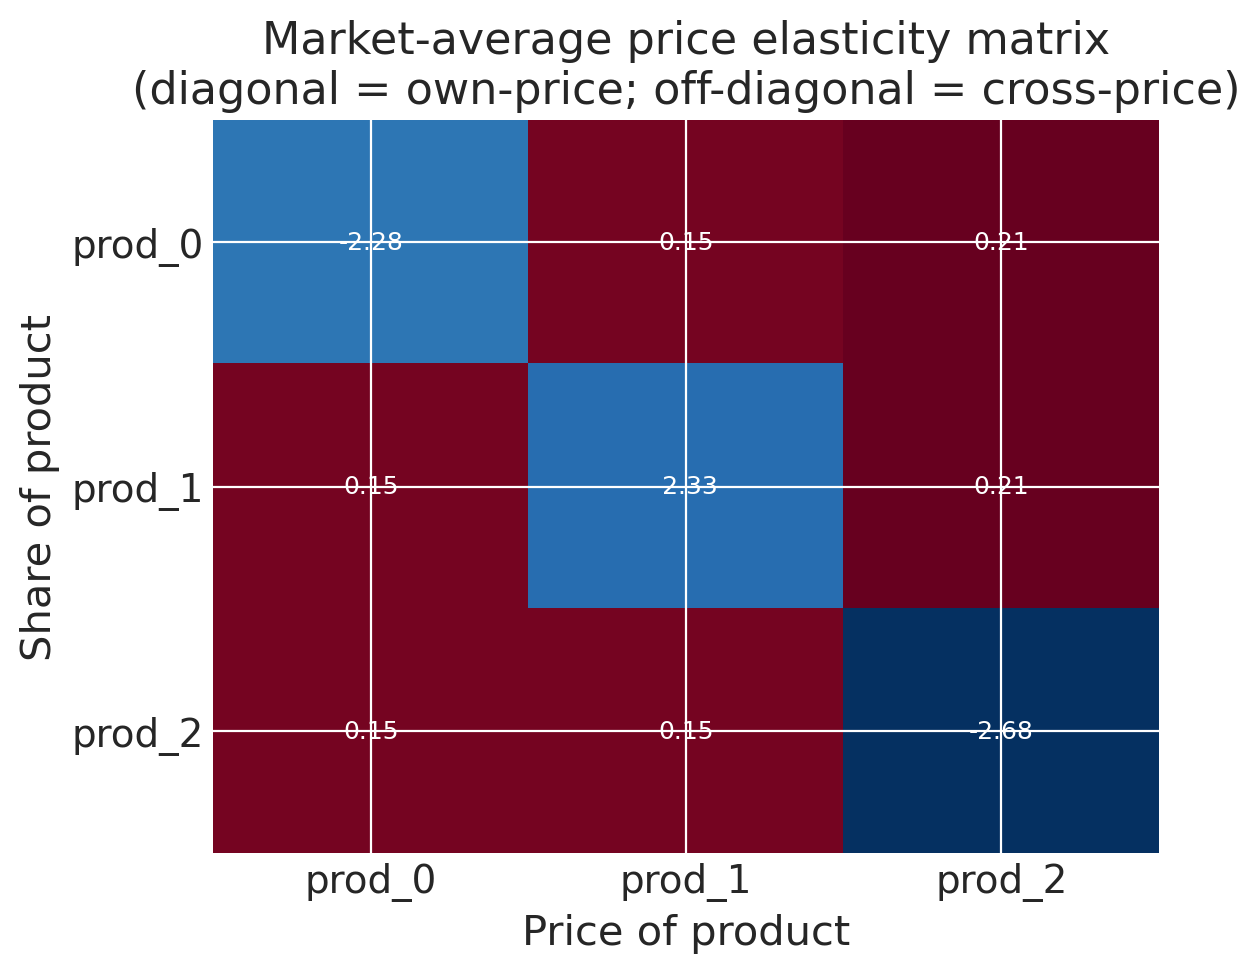

In [12]:
# Average across markets
elast_mean = elast.mean(dim="market").values  # (J, J)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(elast_mean, cmap="RdBu_r", aspect="auto")
# plt.colorbar(im, ax=ax, label='Elasticity')
ax.set_xticks(range(model._J))
ax.set_yticks(range(model._J))
ax.set_xticklabels(model._inside_products)
ax.set_yticklabels(model._inside_products)
ax.set_xlabel("Price of product")
ax.set_ylabel("Share of product")
ax.set_title(
    "Market-average price elasticity matrix\n"
    "(diagonal = own-price; off-diagonal = cross-price)"
)
for i in range(model._J):
    for j in range(model._J):
        ax.text(
            j,
            i,
            f"{elast_mean[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="white",
        )
plt.tight_layout()
plt.show()

### Posterior distribution of the market-averaged own elasticity

The heatmap above shows the posterior *mean* elasticity per cell. To see the
**uncertainty** around each product's own-price elasticity, we average across
markets *per posterior sample* and plot the resulting one-dimensional posterior:

$$
\bar{\varepsilon}_{jj}(s) = \frac{1}{M} \sum_m \varepsilon_{jj}(m, s)
$$

This produces one value per posterior sample per product — the *typical* own-price
elasticity for that SKU across the panel — yielding a clean unimodal posterior
whose width reflects joint uncertainty in `α_r`, `σ_random`, and `ξ`.

A naïve flatten of `(sample × market)` into a single density would plot a
multi-modal mixture, with one mode per market, and obscure the genuine
posterior uncertainty.


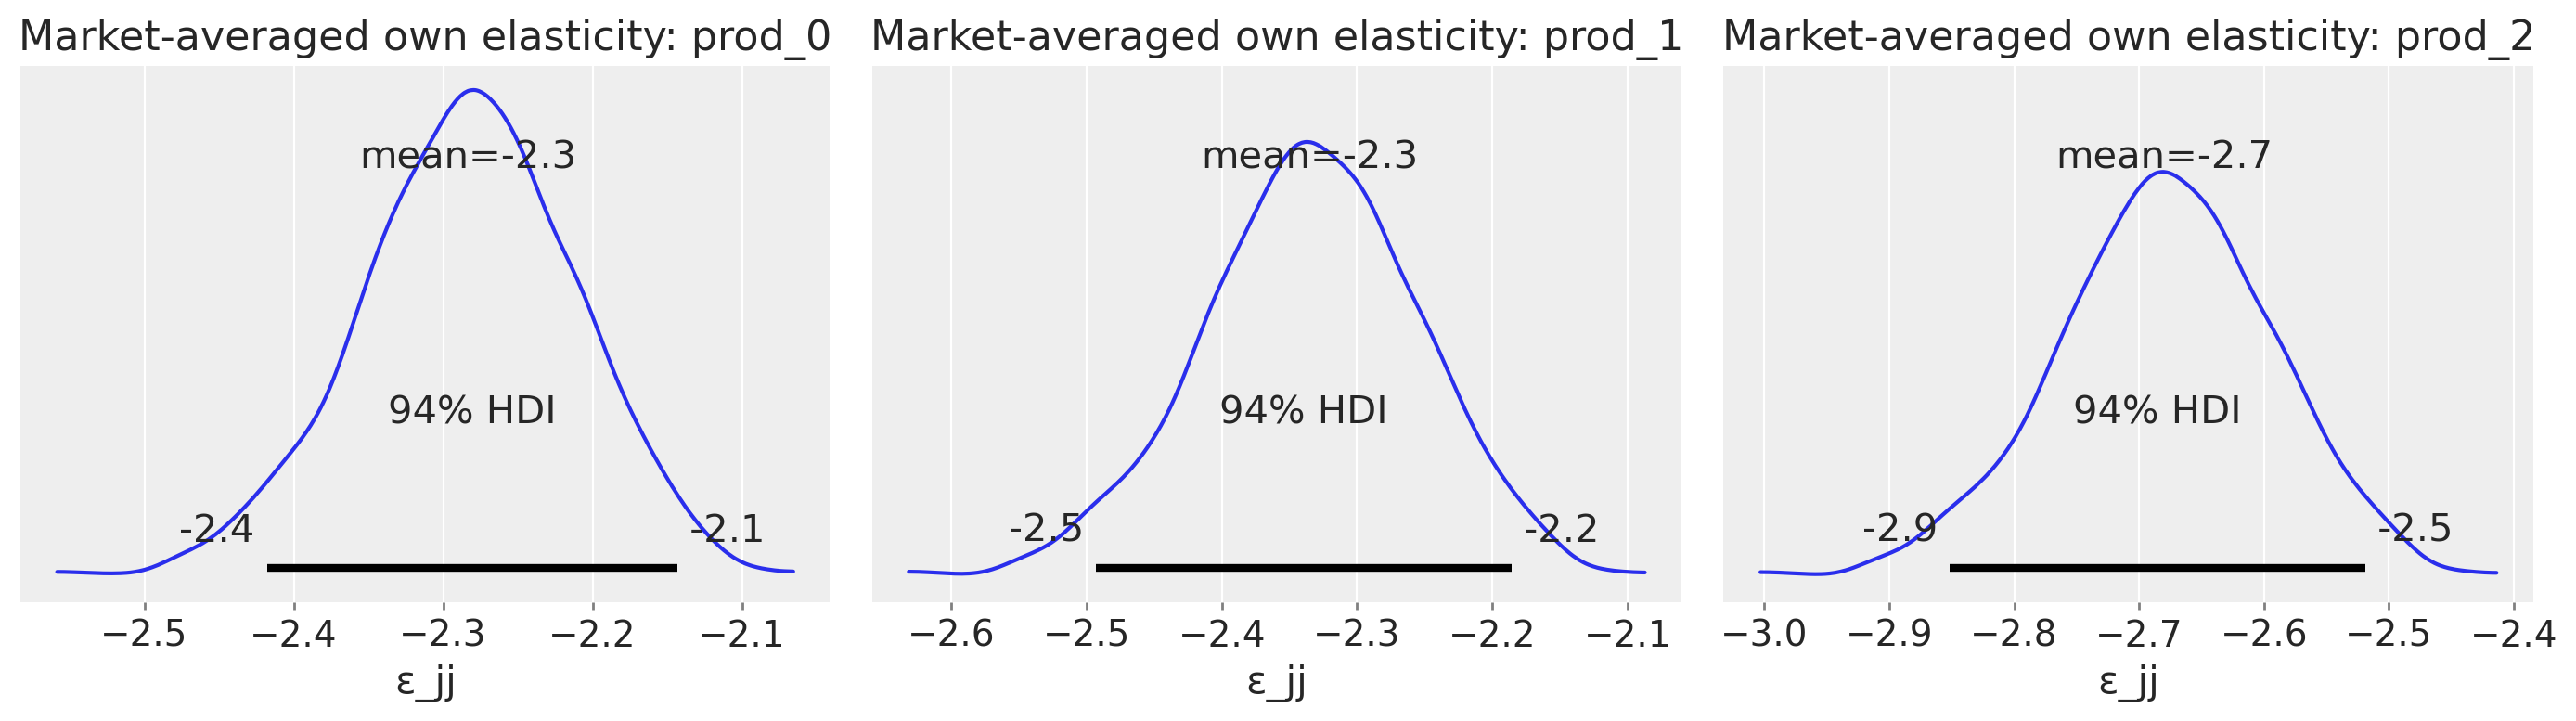

In [13]:
# Posterior distribution of own-price elasticity for the first product
elast = model.elasticities(at="mean", n_samples=2000)  # was 300
elast_samples = model.elasticities(at="samples", n_samples=2000)  # was 300

fig, axs = plt.subplots(1, model._J, figsize=(14, 4), sharey=True)
for j, (ax, pname) in enumerate(zip(axs, model._inside_products, strict=True)):
    # Average across markets per posterior sample → smooth 1D posterior
    own_avg = elast_samples.values[:, :, j, j].mean(axis=1)  # (sample,)
    az.plot_posterior({"own_ε": own_avg}, var_names=["own_ε"], ax=ax)
    ax.set_title(f"Market-averaged own elasticity: {pname}")
    ax.set_xlabel("ε_jj")
plt.tight_layout()

### Per-market variation in own-price elasticity

Averaging across markets hides genuine *cross-market* heterogeneity: the same
product can be more elastic in markets where its baseline share is small or its
realised price is high. The forest plot below shows the per-market 94 % HDI of
`prod_0`'s own-price elasticity — one row per market — using the full posterior.

The horizontal spread of the interval *centres* is the structural across-market
variation that the market-averaged plot collapsed; the *width* of each interval
is per-market posterior uncertainty (typically wider in markets with sparse
shares or extreme prices).


Text(0.5, 1.0, 'Own-price elasticity for prod_0, per market')

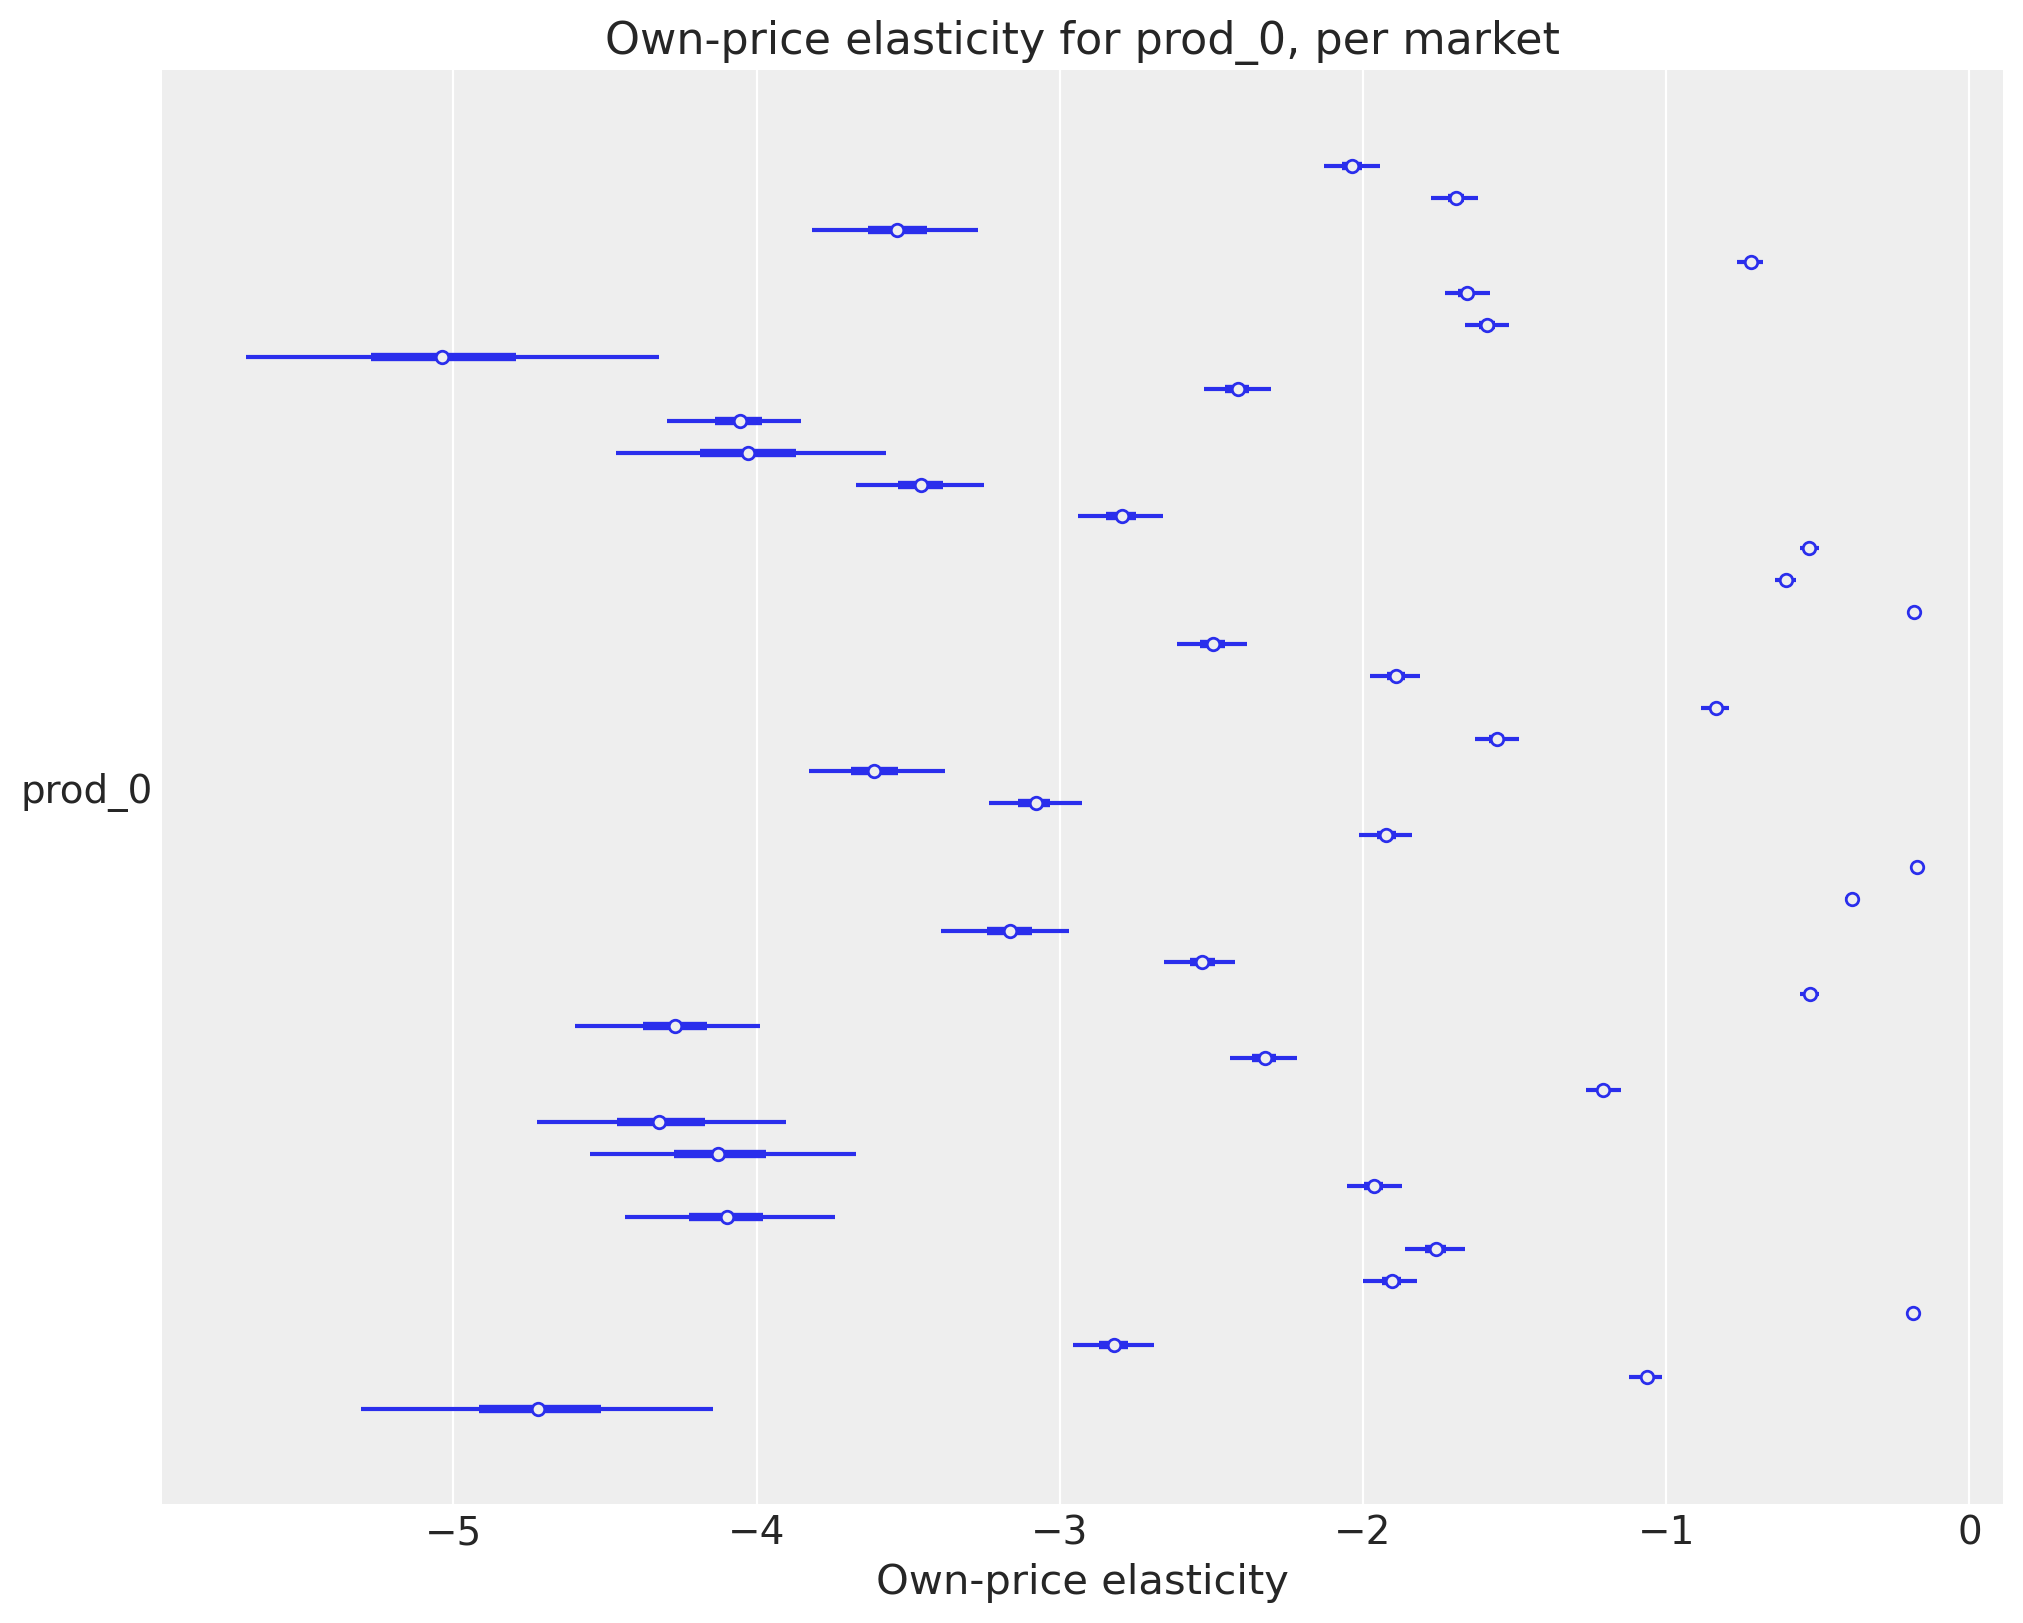

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
own = elast_samples.values[:, :, 0, 0]  # (sample, market) for prod_0
az.plot_forest(
    {"prod_0": own.T},  # (market, sample)
    combined=False,
    ax=ax,
)
ax.set_xlabel("Own-price elasticity")
ax.set_title("Own-price elasticity for prod_0, per market")

## 7. Counterfactual pricing

`counterfactual_shares(price_change=...)` holds the latent demand shock ξ_jt
constant (read directly from the posterior) and re-evaluates the share equation
at new prices. This is the structurally correct counterfactual: it asks *given
the same unobserved market conditions*, what would market shares be at the new
prices?

We examine a **10 % price hike on the first product**:
- its own share should fall (consumers substitute away)
- rival shares and the outside good should rise


In [15]:
target_product = model._inside_products[0]
print(f"Applying 10% price hike to: {target_product}")

baseline_cf = model.counterfactual_shares(price_change=None, n_samples=300)
shocked_cf = model.counterfactual_shares(
    price_change={target_product: 0.10}, n_samples=300
)

baseline_s = baseline_cf["s_inside"].mean(dim="sample").values  # (M, J)
shocked_s = shocked_cf["s_inside"].mean(dim="sample").values
delta_s = shocked_s - baseline_s  # share change

baseline_s_out = baseline_cf["s_outside"].mean(dim="sample").values  # (M,)
shocked_s_out = shocked_cf["s_outside"].mean(dim="sample").values

print("\nMarket-average share changes after 10% price hike on", target_product)
print("-" * 55)
for j, pname in enumerate(model._inside_products):
    b = baseline_s[:, j].mean()
    s = shocked_s[:, j].mean()
    print(f"  {pname:<12}  baseline={b:.4f}  shocked={s:.4f}  Δ={s - b:+.4f}")
print(
    f"  {'outside':<12}  baseline={baseline_s_out.mean():.4f}  "
    f"shocked={shocked_s_out.mean():.4f}  "
    f"Δ={shocked_s_out.mean() - baseline_s_out.mean():+.4f}"
)

Applying 10% price hike to: prod_0

Market-average share changes after 10% price hike on prod_0
-------------------------------------------------------
  prod_0        baseline=0.1066  shocked=0.0961  Δ=-0.0105
  prod_1        baseline=0.1419  shocked=0.1432  Δ=+0.0013
  prod_2        baseline=0.0851  shocked=0.0861  Δ=+0.0011
  outside       baseline=0.6665  shocked=0.6746  Δ=+0.0081


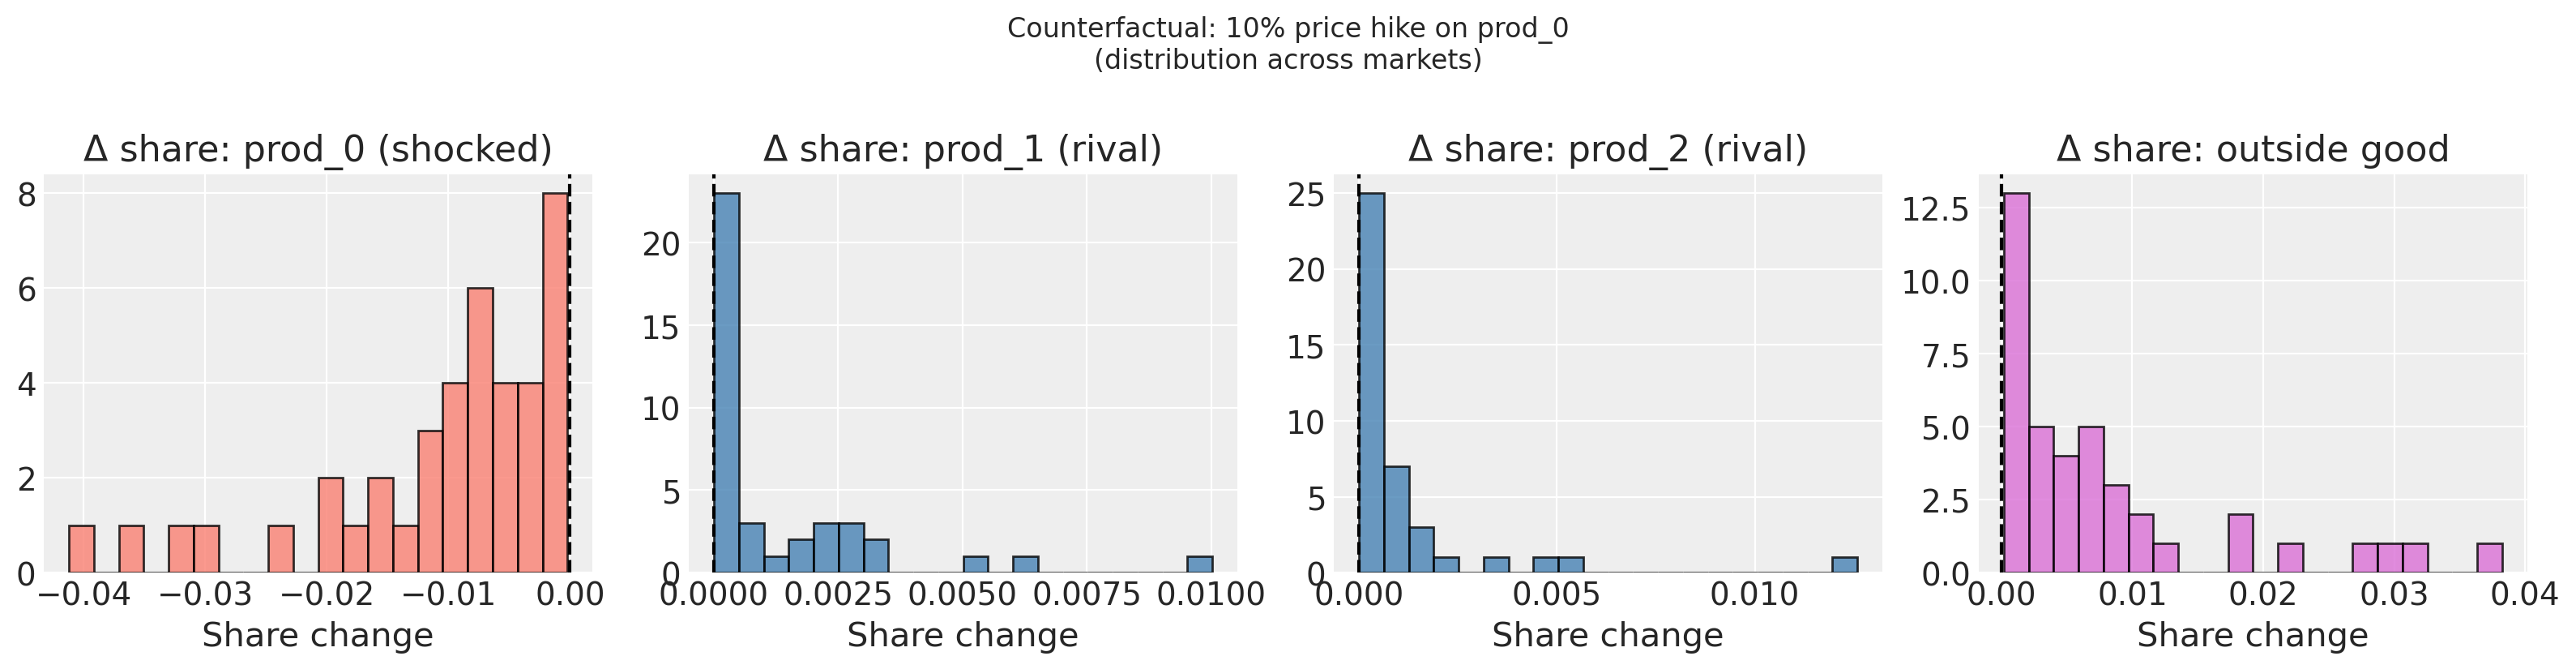

In [16]:
# Visualise share-change distributions across markets
fig, axs = plt.subplots(1, model._J + 1, figsize=(16, 4))

for j, (ax, pname) in enumerate(zip(axs[:-1], model._inside_products, strict=True)):
    colour = "salmon" if pname == target_product else "steelblue"
    ax.hist(delta_s[:, j], bins=20, color=colour, alpha=0.8, edgecolor="k")
    ax.axvline(0, color="k", lw=1.5, ls="--")
    ax.set_title(
        f"Δ share: {pname}" + (" (shocked)" if pname == target_product else " (rival)")
    )
    ax.set_xlabel("Share change")

delta_out = shocked_s_out - baseline_s_out
axs[-1].hist(delta_out, bins=20, color="orchid", alpha=0.8, edgecolor="k")
axs[-1].axvline(0, color="k", lw=1.5, ls="--")
axs[-1].set_title("Δ share: outside good")
axs[-1].set_xlabel("Share change")

plt.suptitle(
    f"Counterfactual: 10% price hike on {target_product}\n"
    "(distribution across markets)",
    y=1.02,
)
plt.tight_layout()
plt.show()

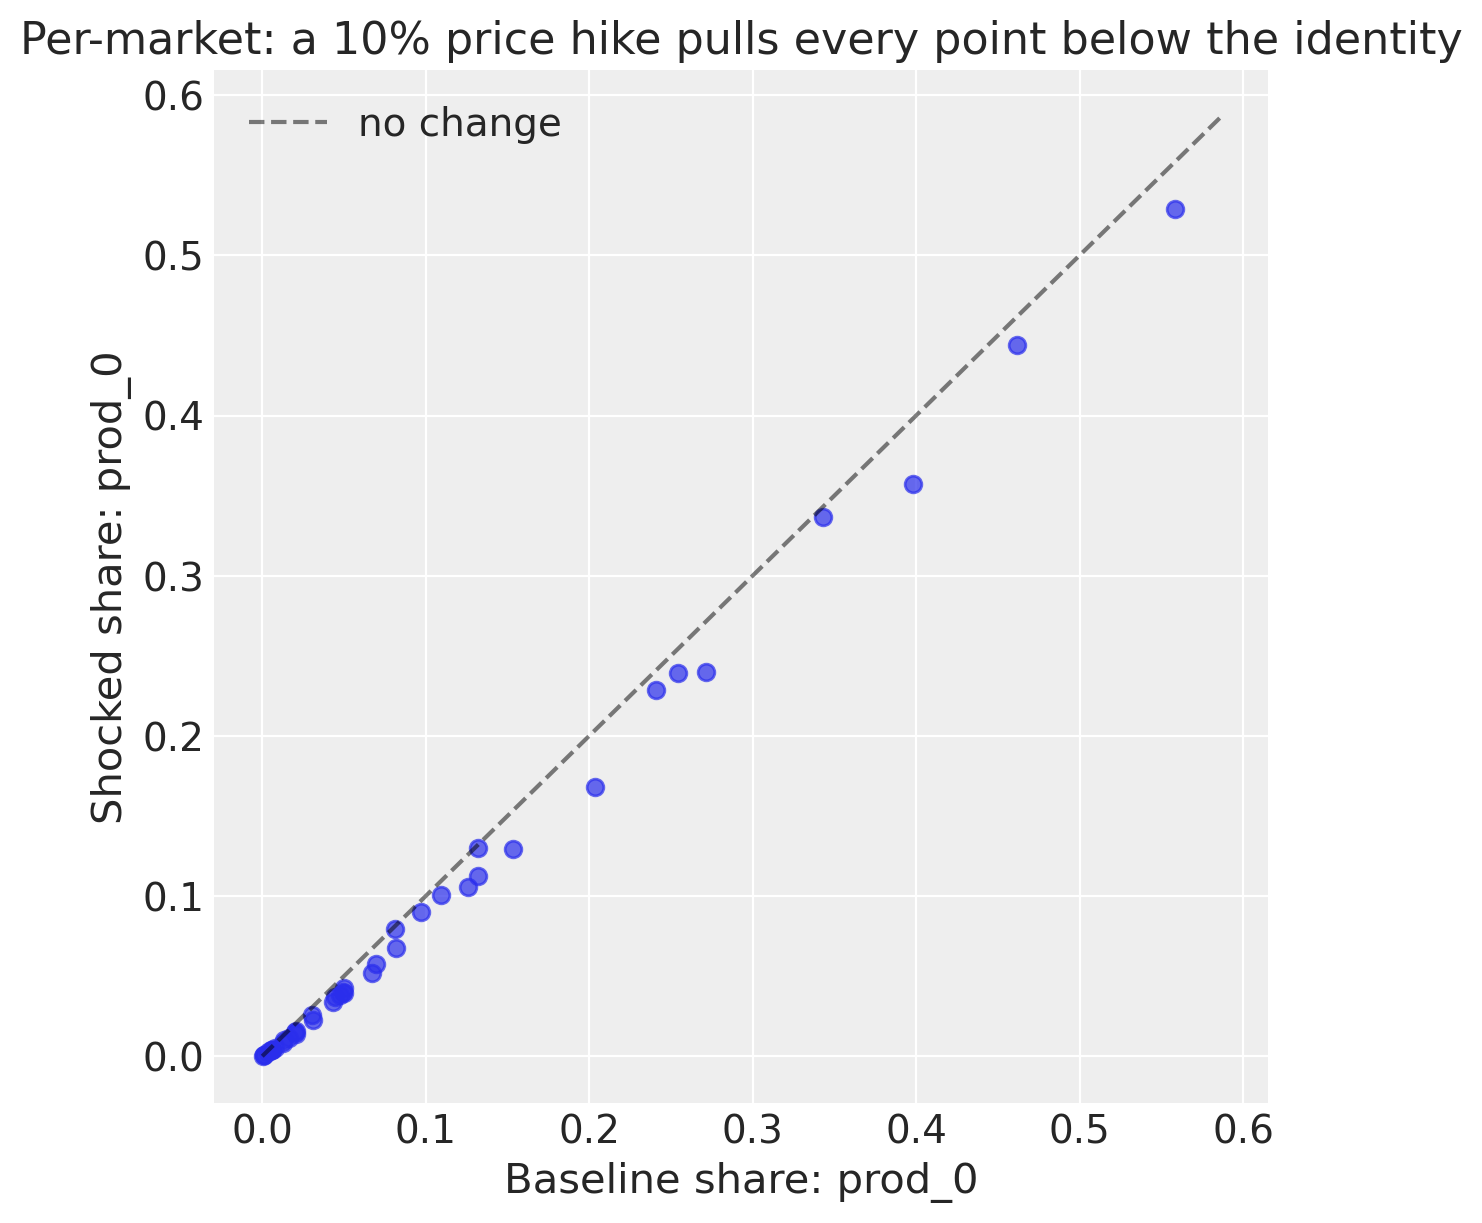

In [17]:
own_idx = model._inside_products.index(target_product)

fig, ax = plt.subplots(figsize=(6, 6))
b = baseline_cf["s_inside"].mean(dim="sample").values[:, own_idx]
s = shocked_cf["s_inside"].mean(dim="sample").values[:, own_idx]
ax.scatter(b, s, alpha=0.7)
lim = max(b.max(), s.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", alpha=0.5, label="no change")
ax.set_xlabel(f"Baseline share: {target_product}")
ax.set_ylabel(f"Shocked share: {target_product}")
ax.set_title("Per-market: a 10% price hike pulls every point below the identity")
ax.legend()

Text(0.5, 1.0, 'Per-market Δshare from 10% price hike on prod_0')

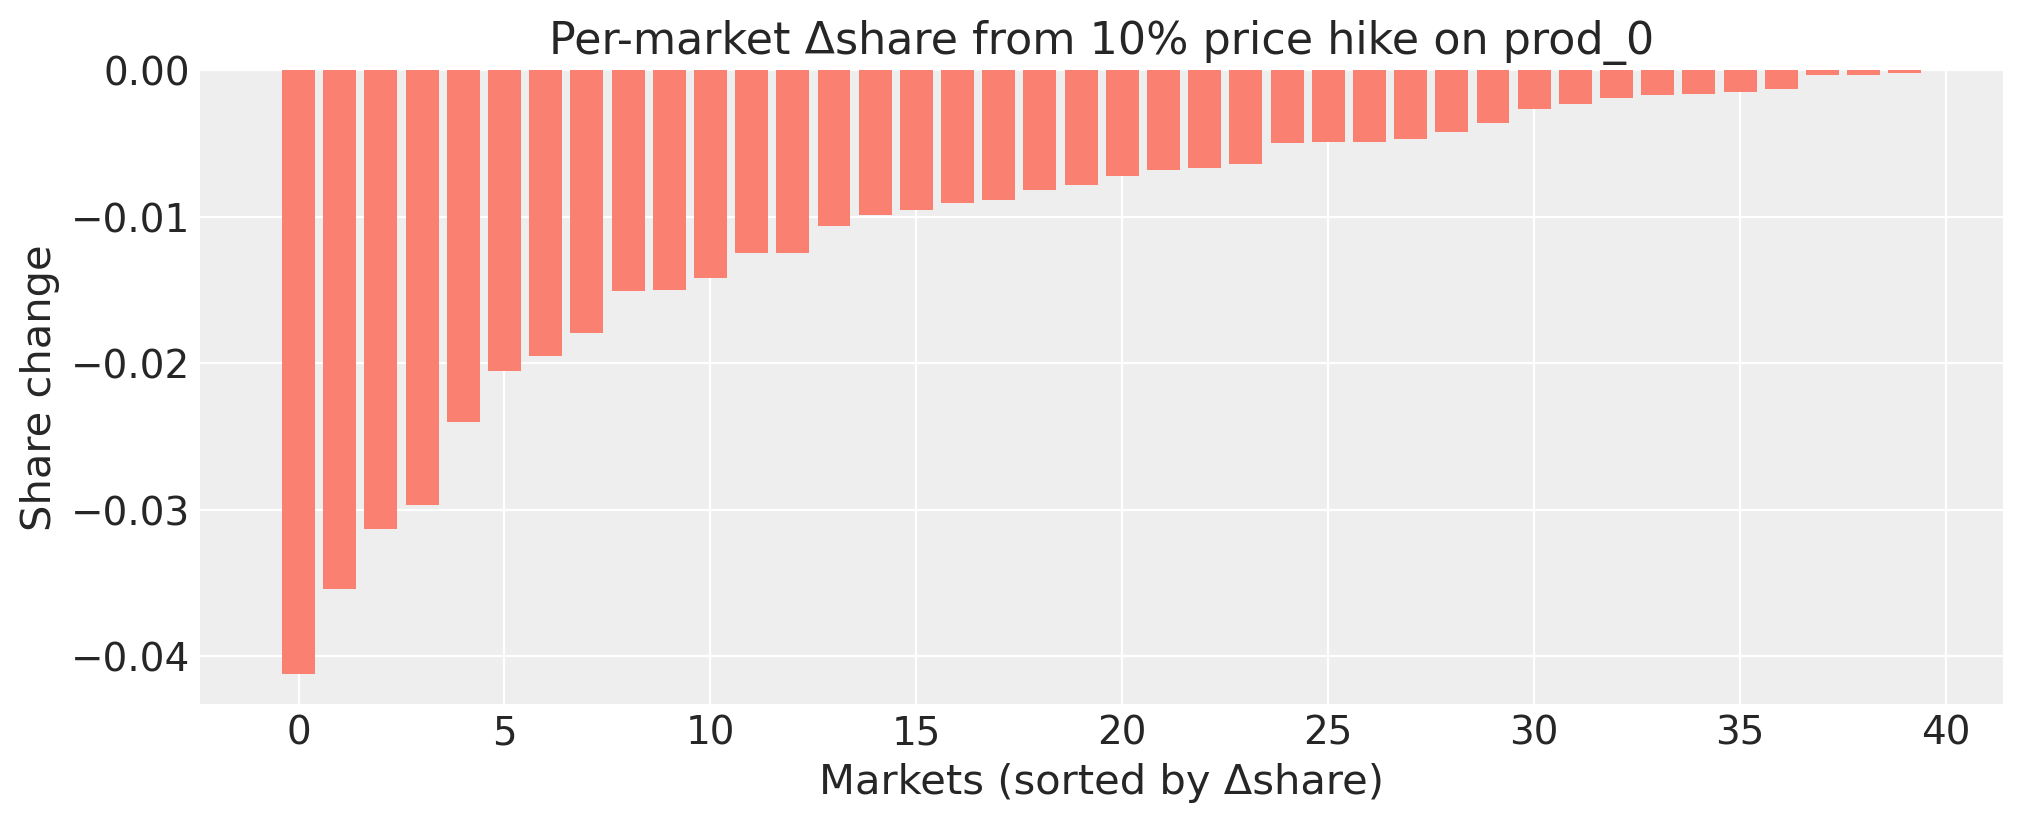

In [18]:
delta = (
    (shocked_cf["s_inside"] - baseline_cf["s_inside"])
    .mean(dim="sample")
    .values[:, own_idx]
)
order = np.argsort(delta)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(delta)), delta[order], color="salmon")
ax.set_xlabel("Markets (sorted by Δshare)")
ax.set_ylabel("Share change")
ax.set_title(f"Per-market Δshare from 10% price hike on {target_product}")

### Time-targeted counterfactuals

Because we constructed the model with `time_col="period"`, the counterfactual
API accepts `periods=` and `regions=` coord-label arguments. Use them to scope
an intervention to a specific time window or geography rather than applying it
across the whole panel.

The cell below applies the same 10% price hike on `prod_0` *only* in periods
10–20. Outside that window the counterfactual shares are bit-identical to the
baseline (no intervention there); inside the window they coincide with the
full-panel counterfactual.


Outside the window: max |Δ vs baseline| = 0.0
Inside the window:  max |Δ vs full-panel cf| = 0.02820211638640896


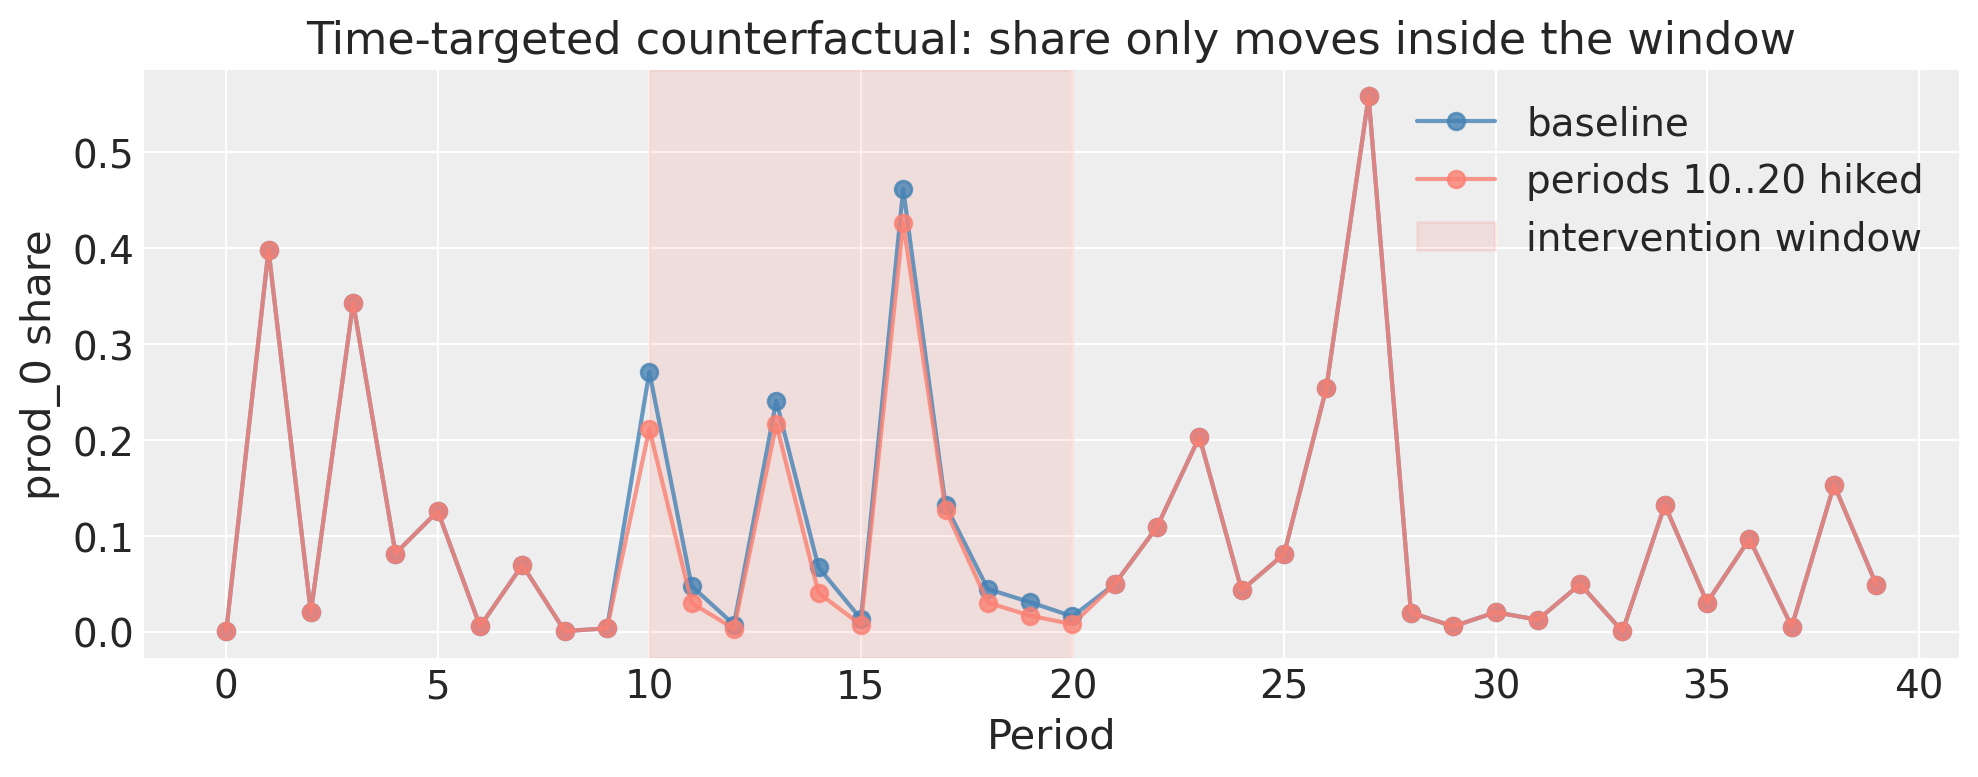

In [32]:
# Apply the 10% hike only in periods 10..20 (inclusive)
window = list(range(10, 21))
cf_window = model.counterfactual_shares(
    price_change={target_product: 0.20},
    periods=window,
    n_samples=300,
)

# The returned dataset carries period+region as non-dim coords on `market`,
# so we can verify the masking directly with xarray.
period_coord = cf_window.coords["period"].values
in_window = np.isin(period_coord, window)

baseline_inside = baseline_cf["s_inside"].mean(dim="sample").values[:, own_idx]
shocked_window_inside = cf_window["s_inside"].mean(dim="sample").values[:, own_idx]
shocked_full_inside = shocked_cf["s_inside"].mean(dim="sample").values[:, own_idx]

print(
    "Outside the window: max |Δ vs baseline| =",
    np.abs(shocked_window_inside[~in_window] - baseline_inside[~in_window]).max(),
)
print(
    "Inside the window:  max |Δ vs full-panel cf| =",
    np.abs(shocked_window_inside[in_window] - shocked_full_inside[in_window]).max(),
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    period_coord, baseline_inside, "o-", color="steelblue", label="baseline", alpha=0.8
)
ax.plot(
    period_coord,
    shocked_window_inside,
    "o-",
    color="salmon",
    label="periods 10..20 hiked",
    alpha=0.8,
)
ax.axvspan(10, 20, color="salmon", alpha=0.15, label="intervention window")
ax.set_xlabel("Period")
ax.set_ylabel(f"{target_product} share")
ax.set_title("Time-targeted counterfactual: share only moves inside the window")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Hierarchical pooling across regions

When markets belong to distinct geographic regions, `region_col` activates
partial pooling across regions:

```
α_pop ~ N(0, 2)    τ_α ~ HalfNormal(1)
α_r   = α_pop + τ_α · α_r_raw        α_r_raw ~ N(0, 1)
```

This is the headline differentiator vs GMM BLP: thin markets are shrunk
toward the population mean, giving stable inference without discarding data.

We generate a 3-region panel with genuine region-level preference heterogeneity
(`region_heterogeneity=0.6`) and verify that `τ_α` (the between-region SD)
has posterior mass away from zero.


In [20]:
df_multi, truth_multi = generate_blp_panel(
    T=20,
    J=3,
    K=2,
    L=2,
    R_geo=3,
    region_heterogeneity=0.6,
    true_alpha=-2.0,
    sigma_alpha=0.5,
    instrument_strength=0.7,
    price_xi_corr=0.5,
    market_size=4_000,
    n_dgp_draws=3_000,
    random_seed=7,
    return_truth=True,
)

print("Regions:", df_multi["region"].unique())
print("Markets per region:", df_multi.groupby("region")["market"].nunique().to_dict())
print("True per-region alpha_r:", np.round(truth_multi["alpha_r"], 3))

Regions: ['r0' 'r1' 'r2']
Markets per region: {'r0': 20, 'r1': 20, 'r2': 20}
True per-region alpha_r: [-1.999 -1.821 -2.164]


In [21]:
model_hier = BayesianBLP(
    market_data=df_multi,
    characteristics=truth_multi["characteristic_cols"],
    instruments=truth_multi["instrument_cols"],
    region_col="region",
    random_coef_on=["price"],
    n_mc_draws=100,
    random_seed=0,
    hierarchical_parameterisation="centered",
)
model_hier.fit(**_FIT_KWARGS)
n_div_hier = int(model_hier.idata.sample_stats["diverging"].values.sum())
print(f"Divergences: {n_div_hier}")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.06,63
,2000,0,0.07,63
,2000,0,0.08,63
,2000,0,0.07,63


Divergences: 0


In [22]:
az.summary(
    model_hier.idata,
    var_names=["alpha_pop", "tau_alpha", "alpha_r"],
    round_to=2,
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_pop,-1.90,0.27,-2.37,-1.30,0.01,0.01,875.25,900.40,1.00
tau_alpha,0.37,0.30,0.06,0.92,0.01,0.01,1715.13,2212.74,1.00
alpha_r[r0],-1.95,0.06,-2.06,-1.84,0.00,0.00,263.42,557.34,1.02
alpha_r[r1],-1.78,0.06,-1.90,-1.67,0.00,0.00,253.10,586.06,1.01
alpha_r[r2],-2.09,0.06,-2.21,-1.98,0.00,0.00,237.90,524.15,1.02


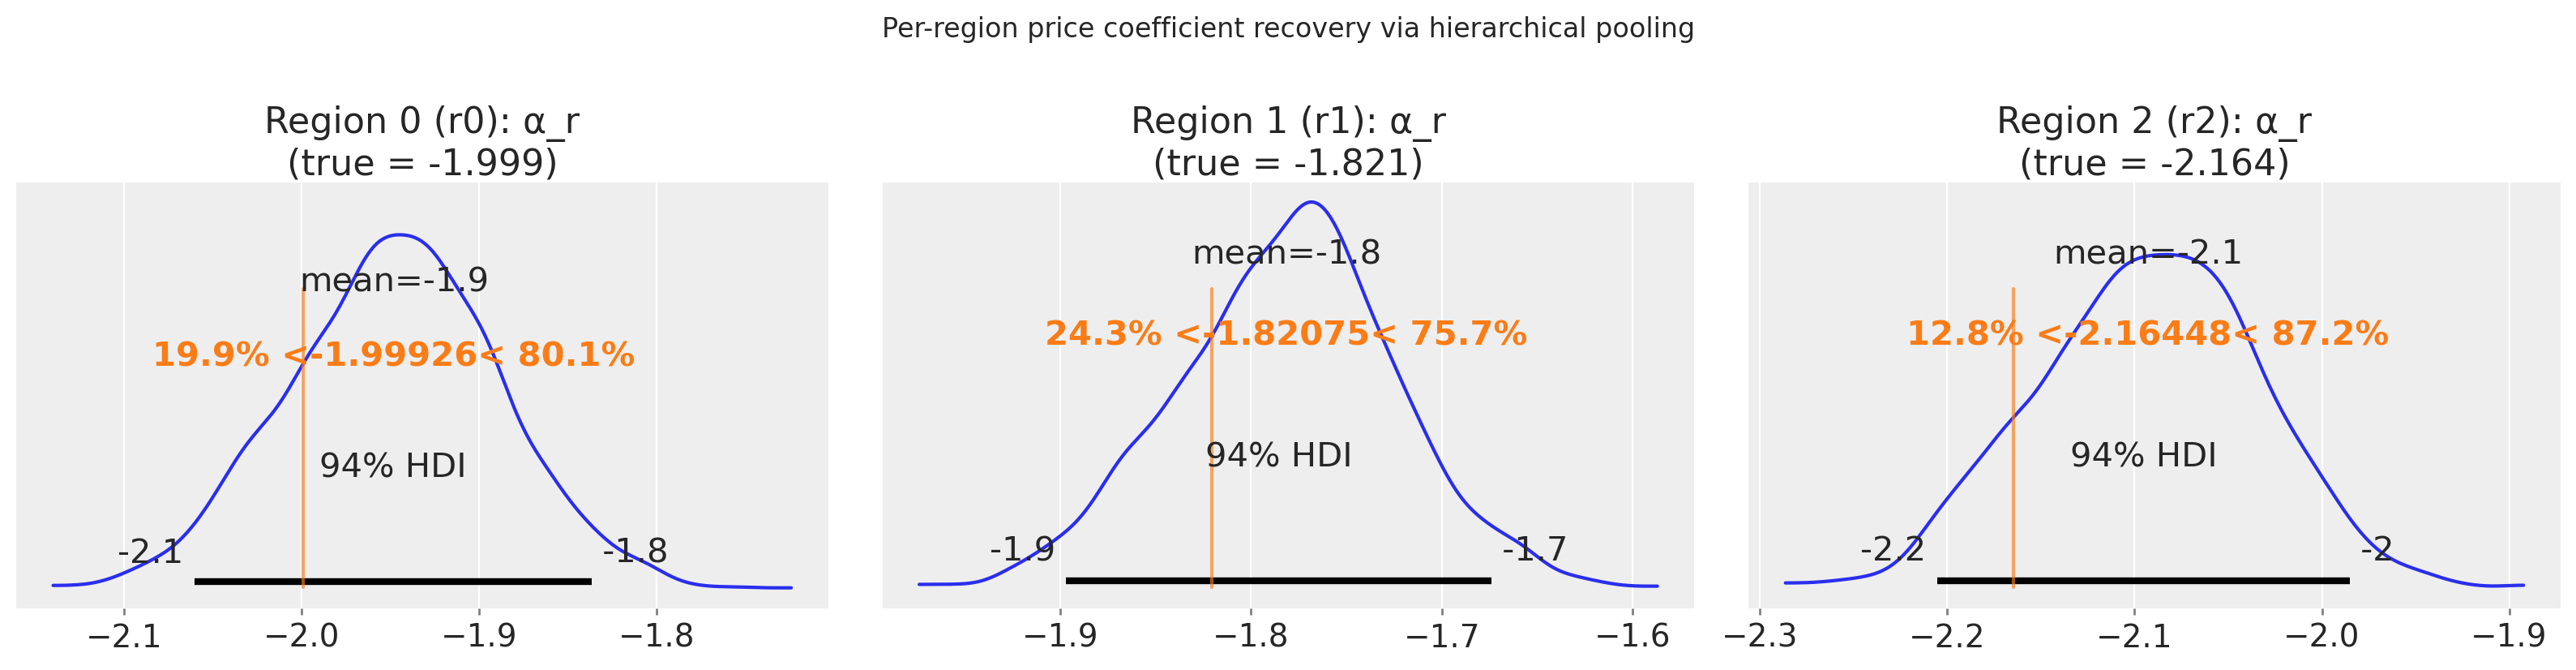

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# Match the model's region ordering exactly
region_labels = (
    model_hier._regions
)  # or list(model_hier.idata.posterior.coords["region"].values)

for r, (ax, region_label, true_val) in enumerate(
    zip(axs, region_labels, truth_multi["alpha_r"], strict=True)
):
    az.plot_posterior(
        model_hier.idata,
        var_names=["alpha_r"],
        coords={"region": region_label},
        ref_val=float(true_val),
        ax=ax,
    )
    ax.set_title(f"Region {r} ({region_label}): α_r\n(true = {true_val:.3f})")

plt.suptitle("Per-region price coefficient recovery via hierarchical pooling", y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# tau_alpha: between-region SD should be > 0 under genuine heterogeneity
tau_lo, tau_hi = az.hdi(
    model_hier.idata.posterior["tau_alpha"].values.ravel(), hdi_prob=0.94
)
print(f"tau_alpha 94% HDI: [{tau_lo:.3f}, {tau_hi:.3f}]")
print("tau_alpha lower bound > 0:", tau_lo > 0)

tau_alpha 94% HDI: [0.062, 0.915]
tau_alpha lower bound > 0: True


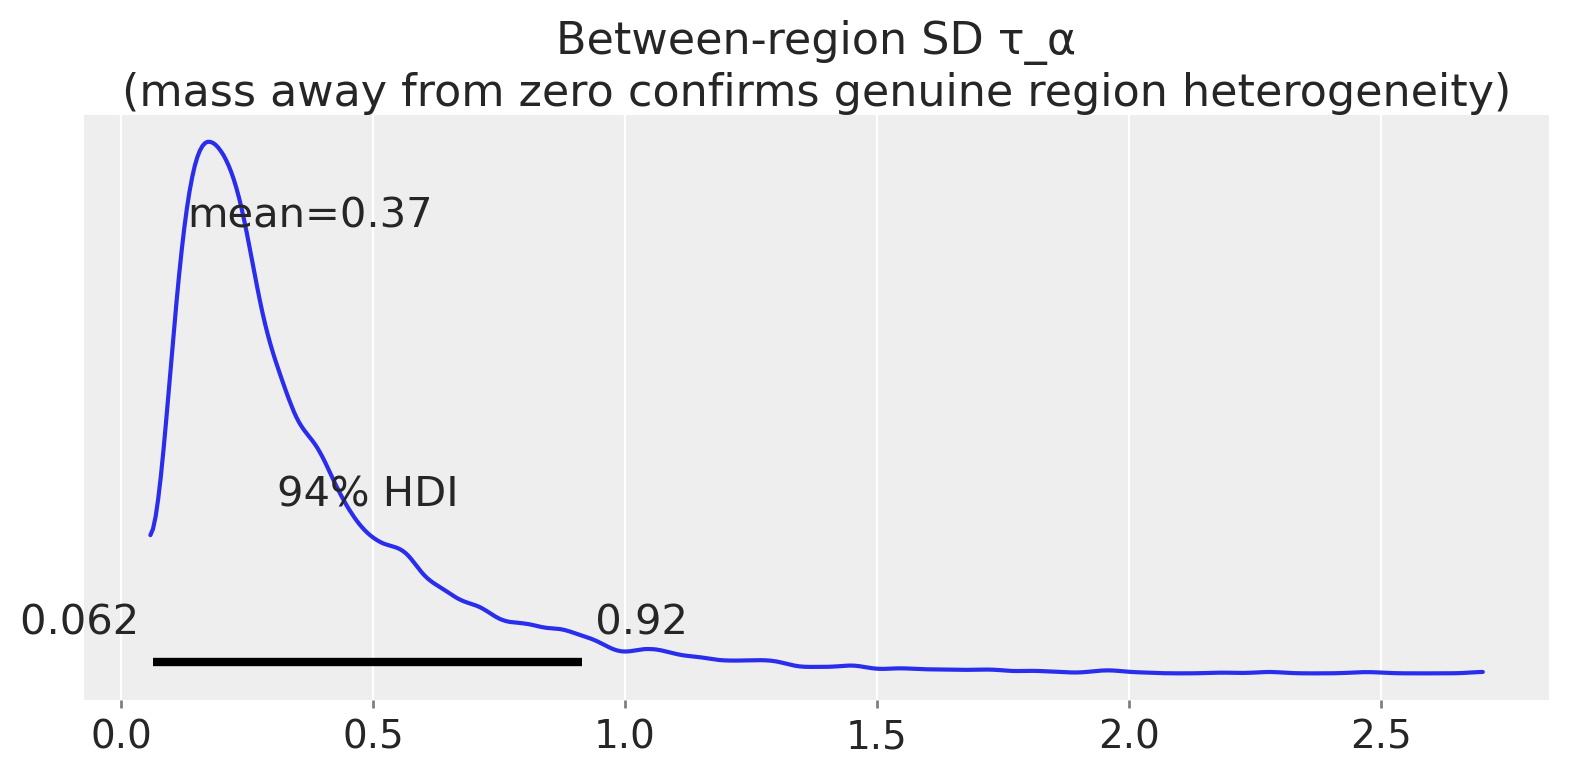

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
az.plot_posterior(model_hier.idata, var_names=["tau_alpha"], ax=ax)
ax.set_title(
    "Between-region SD τ_α\n(mass away from zero confirms genuine region heterogeneity)"
)
plt.tight_layout()
plt.show()

## 9. Model interpretation and structural story

### What the model estimates

- **`alpha_r`** — the mean price coefficient in region `r`. Because prices are
  endogenous (firms observe ξ before setting prices), naive OLS on shares would
  absorb the price–ξ correlation into `alpha`, biasing it toward zero. The joint
  model with instruments removes this bias through the conditional decomposition
  `ξ̃ | η ~ N(ρ · σ_ξ/σ_η · η, σ_ξ · √(1−ρ²))`.

- **`rho_price_xi`** — the endogeneity correlation ρ. A positive value (prices
  rise with positive demand shocks) is the standard finding in scanner data and
  confirms that instruments are doing work.

- **`sigma_random`** — consumer heterogeneity in price sensitivity. This drives
  the own-price elasticities away from the IIA logit value and produces a
  realistic cross-price substitution pattern.

- **`xi`** — the latent product-market demand shock. Markets where ξ_jt is high
  are those where product j was especially popular beyond what observables explain
  (a promotion, a competitor stockout, a viral moment). Monitoring the posterior
  mean of ξ over time can detect these events retrospectively.

### Counterfactual validity

The counterfactual holds ξ fixed at its posterior draw. This is the correct
semantic: we are asking *under the same unobserved market conditions*, what would
shares be at new prices? It is not a causal claim about what would happen if a
firm actually changed prices (that would require a supply-side equilibrium model),
but it is the standard in structural demand estimation and is much more credible
than a reduced-form share regression.

### Caveats

- The outside-good definition matters: `market_size` (the category volume that
  determines the outside share) affects every elasticity. Sensitivity analysis
  over `market_size` is recommended.
- Weak instruments inflate posterior credible intervals on `alpha` (Bayesian
  inference stays honest) but also inflate elasticity uncertainty.
- The supply side is not modelled (v1). For merger simulation or optimal pricing,
  a Bertrand-Nash markup equation should be appended.


## 10. Summary

In this notebook we demonstrated the full BayesianBLP workflow:

1. **Data generation** — `generate_blp_panel` with endogenous prices and known truth.
2. **Prior predictive check** — shares sum to 1; priors cover plausible scanner data.
3. **IV fit** — zero divergences; posterior recovers `α`, `β`, `σ_α` inside the 94% HDI.
4. **Endogeneity bias** — dropping instruments biases `α` toward zero by `≈0.16`;
   instruments correct this.
5. **Elasticities** — own-price negative (−3 to −5 range); cross-price positive;
   full posterior uncertainty available.
6. **Counterfactual** — a 10% price hike on one product reduces its share,
   raises rivals and the outside good, with calibrated posterior uncertainty.
7. **Hierarchical pooling** — `τ_α > 0` confirms genuine region heterogeneity;
   per-region `α_r` recovers truth via partial pooling.


In [26]:
# 1. ESS / r-hat for the parameters that drive elasticities
az.summary(model.idata, var_names=["alpha_r", "beta_r", "sigma_random", "rho_price_xi"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_r[all],-2.013,0.065,-2.138,-1.898,0.005,0.003,197.0,394.0,1.02
"beta_r[all, x_0]",0.791,0.050,0.696,0.883,0.002,0.001,413.0,865.0,1.01
"beta_r[all, x_1]",1.189,0.028,1.138,1.242,0.002,0.001,301.0,610.0,1.02
sigma_random[price],0.548,0.045,0.469,0.637,0.002,0.001,364.0,821.0,1.01
rho_price_xi,0.582,0.105,0.391,0.770,0.007,0.004,205.0,443.0,1.02


In [27]:
# 2. Posterior on tau_alpha - bet you find it pinned near 0
az.summary(model_hier.idata, var_names=["tau_alpha"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau_alpha,0.374,0.296,0.062,0.915,0.008,0.009,1715.0,2213.0,1.0


array([[<Axes: ylabel='alpha_r\nr0'>, <Axes: >, <Axes: >],
       [<Axes: ylabel='alpha_r\nr1'>, <Axes: >, <Axes: >],
       [<Axes: xlabel='tau_alpha', ylabel='alpha_r\nr2'>,
        <Axes: xlabel='alpha_r\nr0'>, <Axes: xlabel='alpha_r\nr1'>]],
      dtype=object)

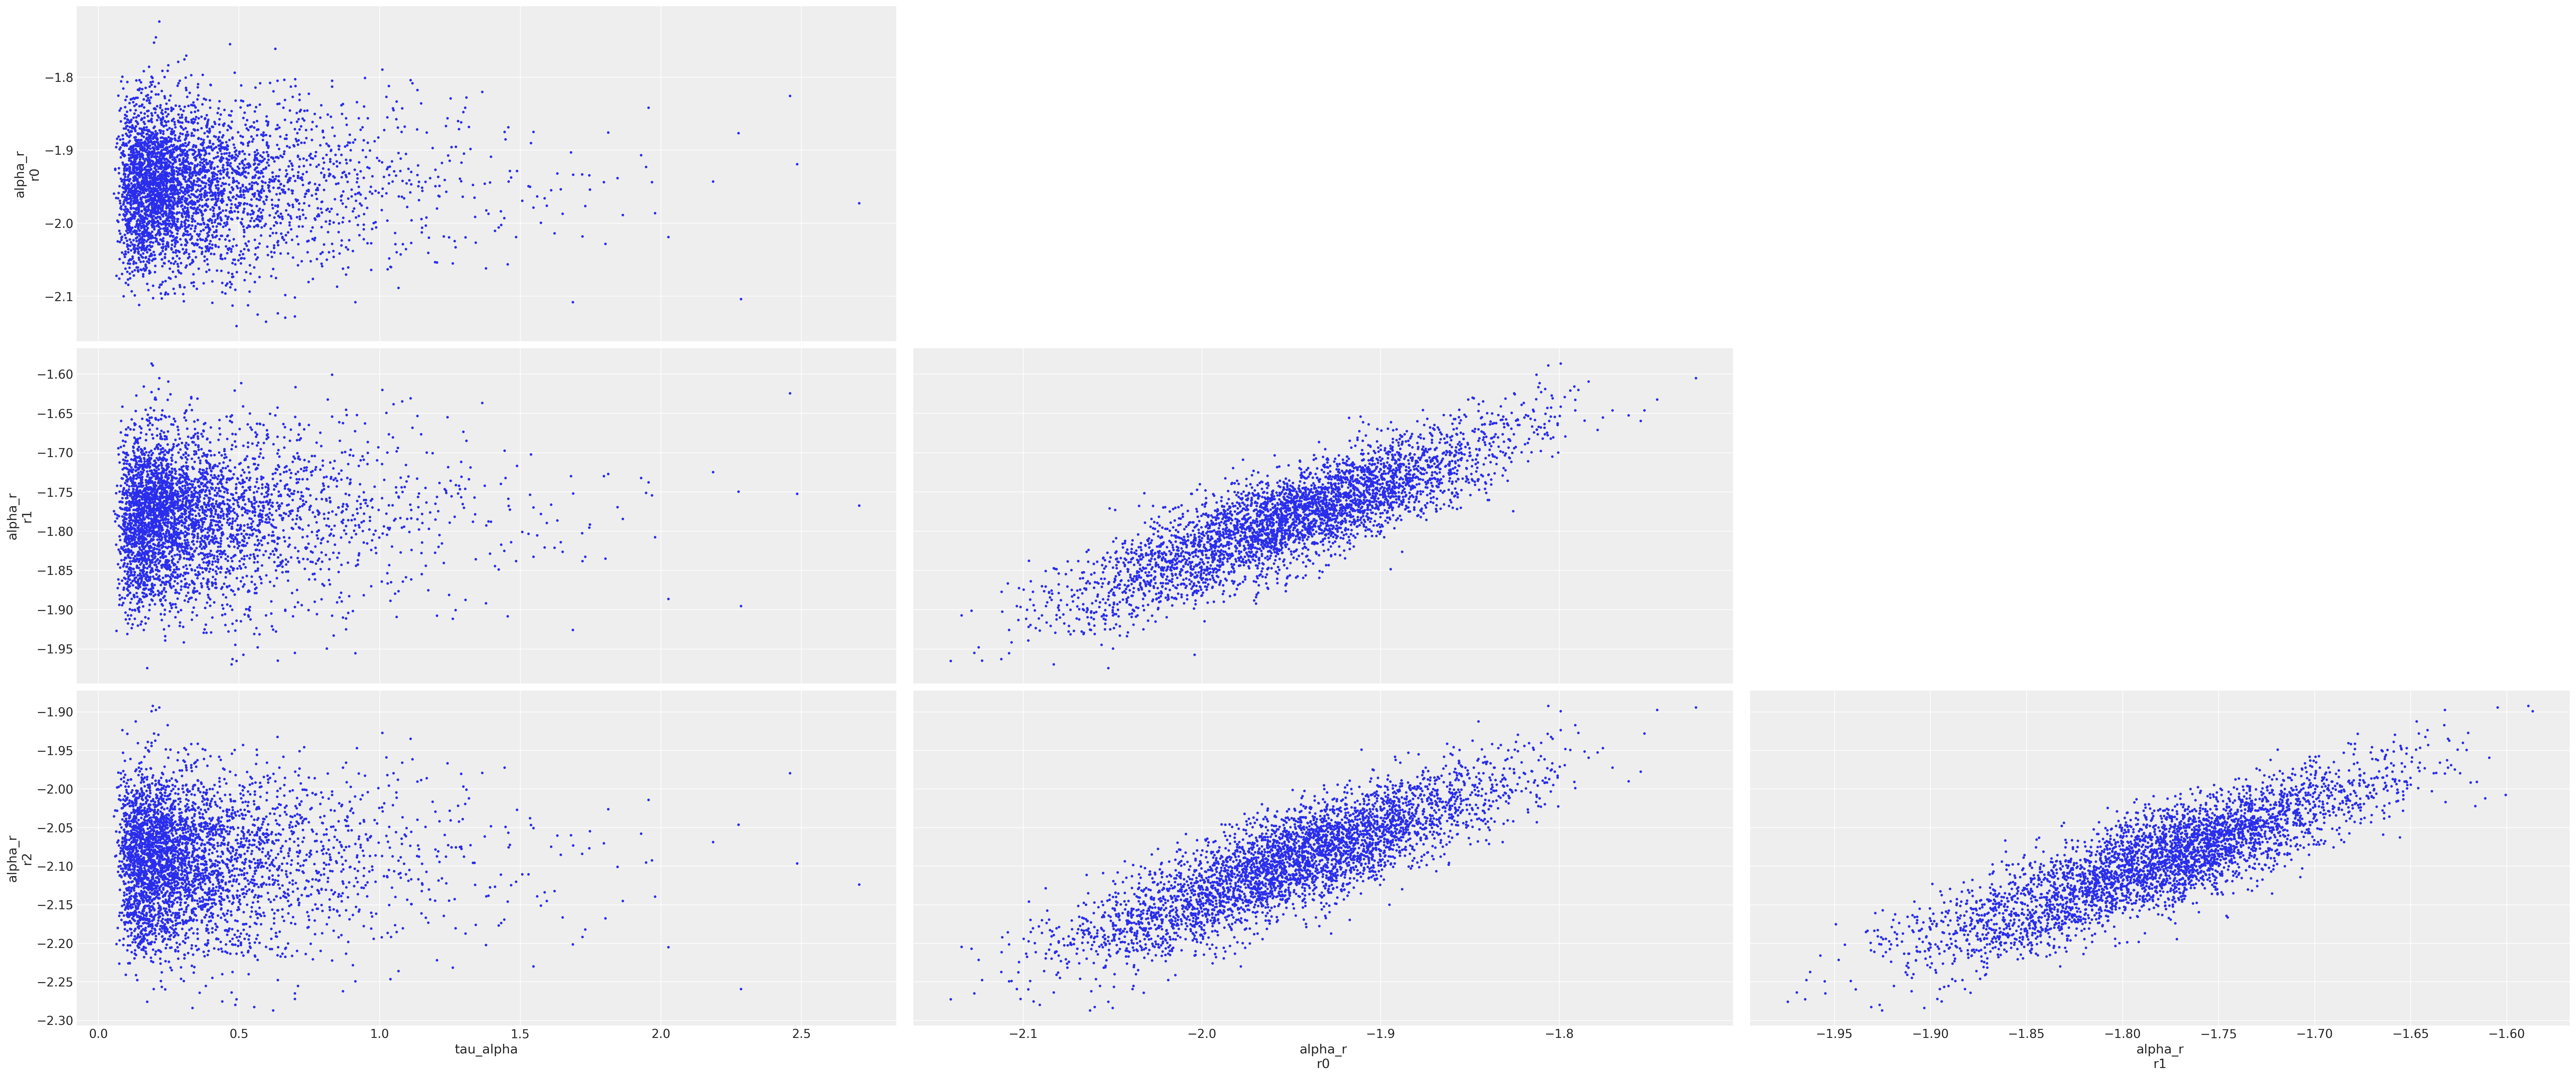

In [28]:
# A. Plot the funnel to confirm
az.plot_pair(
    model_hier.idata,
    var_names=["tau_alpha", "alpha_r"],
    kind="scatter",
    divergences=True,
)
# Expect classic funnel shape if this is the issue

In [29]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing

Last updated: Tue, 28 Apr 2026

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.13.0

pymc_marketing: 0.19.3

arviz         : 0.23.4
matplotlib    : 3.10.9
numpy         : 2.4.3
pymc_marketing: 0.19.3

Watermark: 2.6.0

